In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [4]:
df = pd.read_csv("data/processed/women_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [15]:
result_dict["feat_imp"].head(20)

,Feature,shap_importance,shap_std,mean,std
0,delta_Seed,5.206835,0.058118,0.150124,0.013680
1,delta_quality,2.702698,0.017487,0.124266,0.008038
2,delta_N_wins,2.373516,0.015643,0.008203,0.000922
3,delta_Blk,2.195200,0.021360,0.013893,0.001700
4,delta_Stl_diff,1.899630,0.010350,0.012730,0.001053
5,delta_FGM_perc,1.880923,0.020802,0.118297,0.030695
6,delta_FGM2,1.553786,0.016206,0.054377,0.026302
7,delta_off_edge,1.441418,0.008980,0.008073,0.000620
8,delta_FGM3,1.348028,0.009775,0.006906,0.001009
9,delta_FGM_no_ast_perc,1.253840,0.015185,0.007183,0.000581


OOF score: 13.96533877569374
[2895, 2077, 2518, 644, 1494]


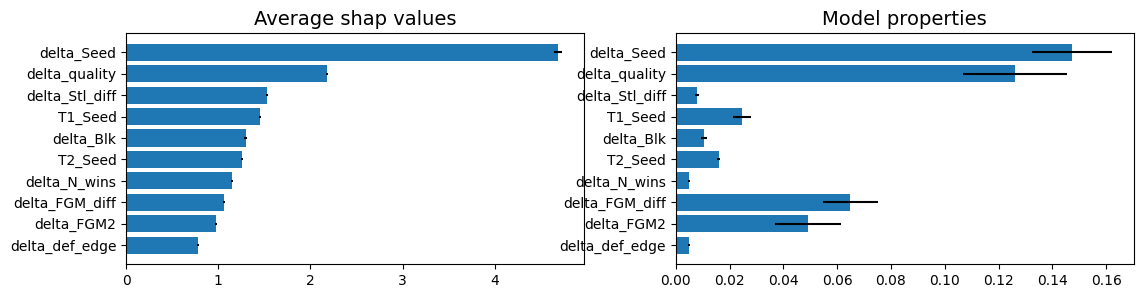

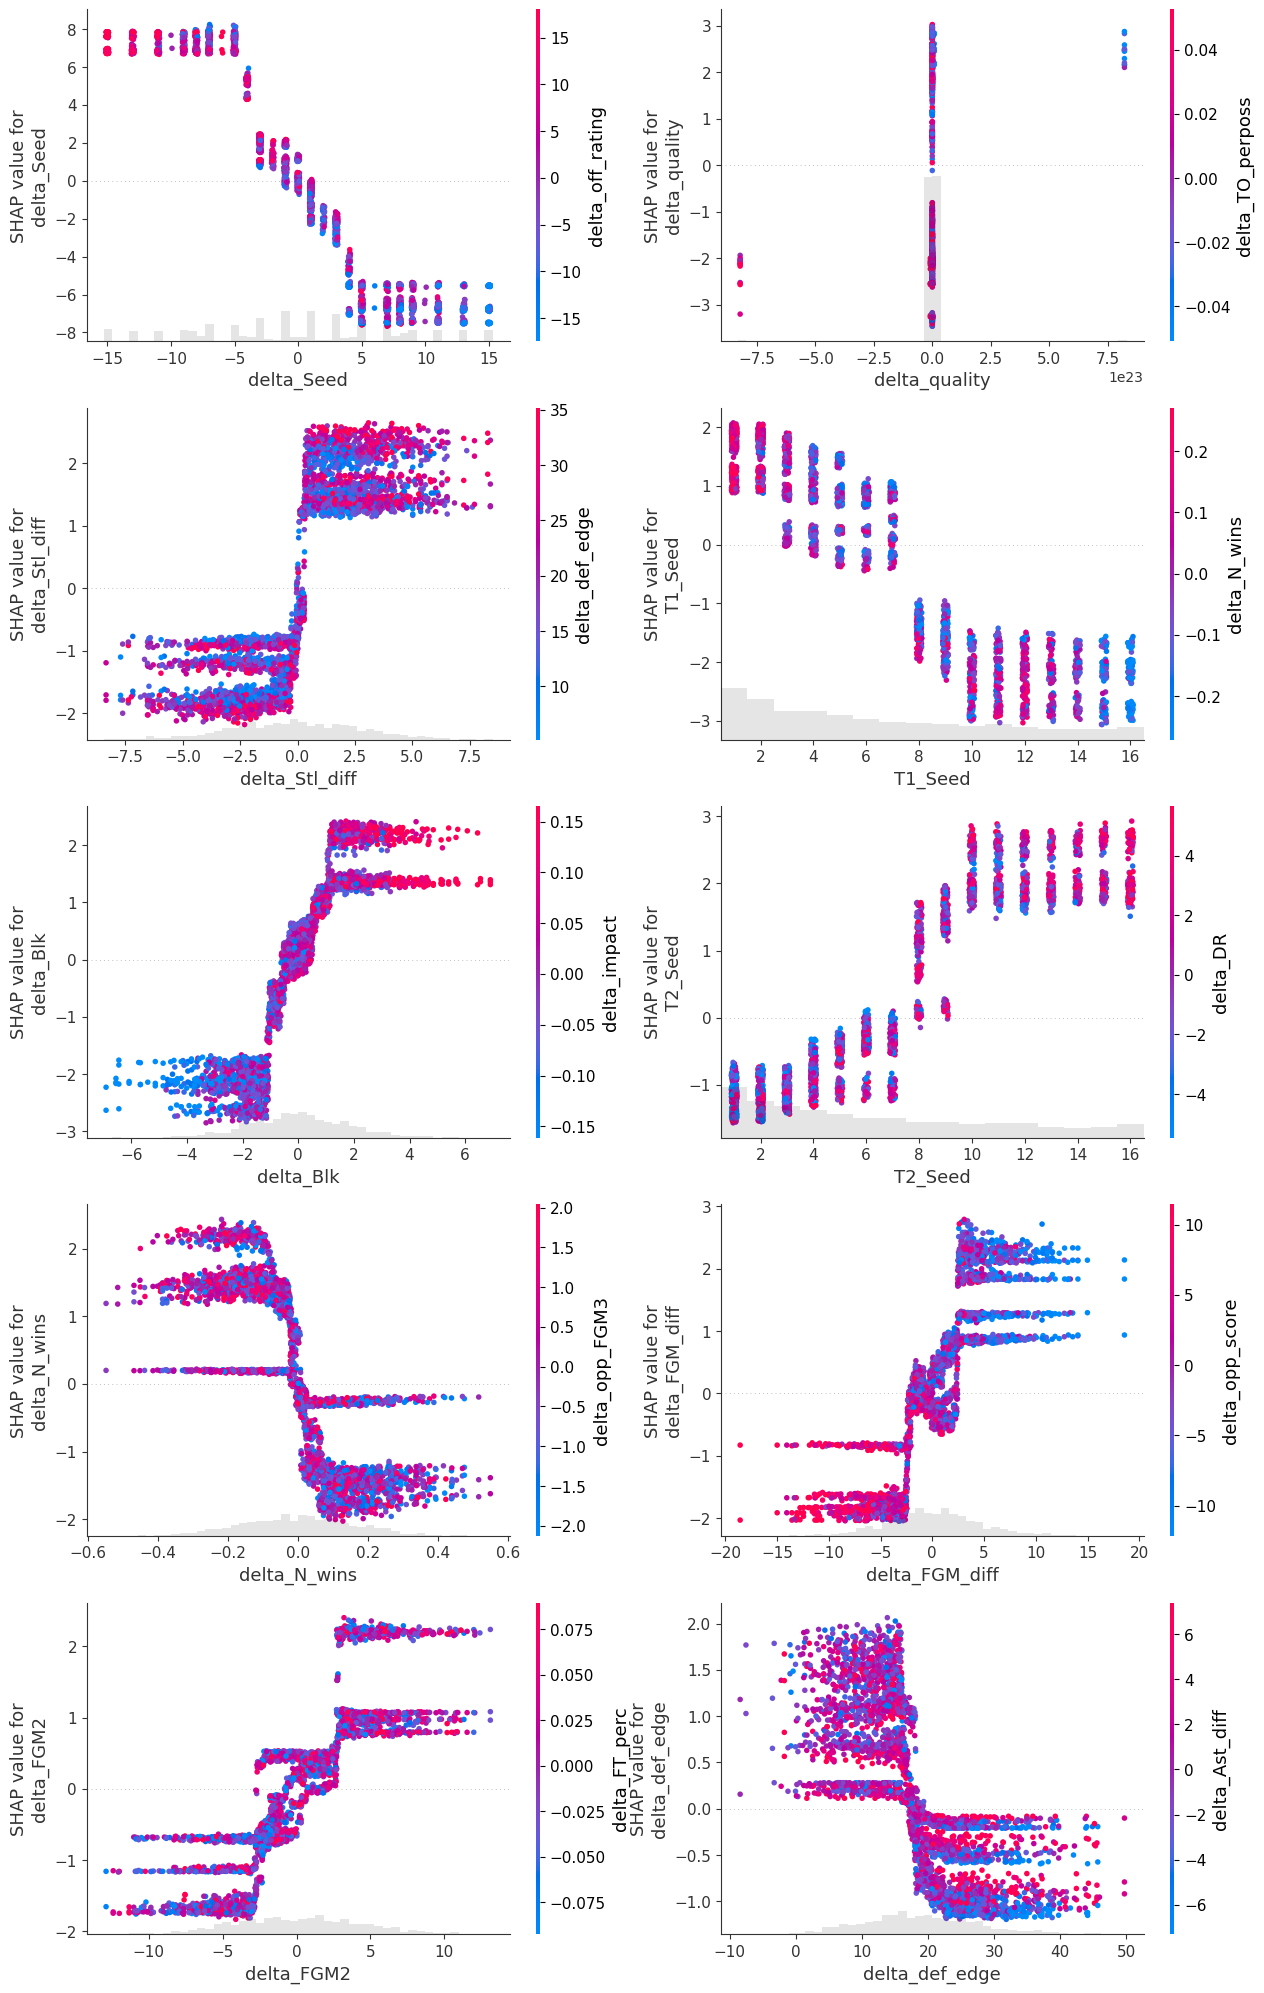

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


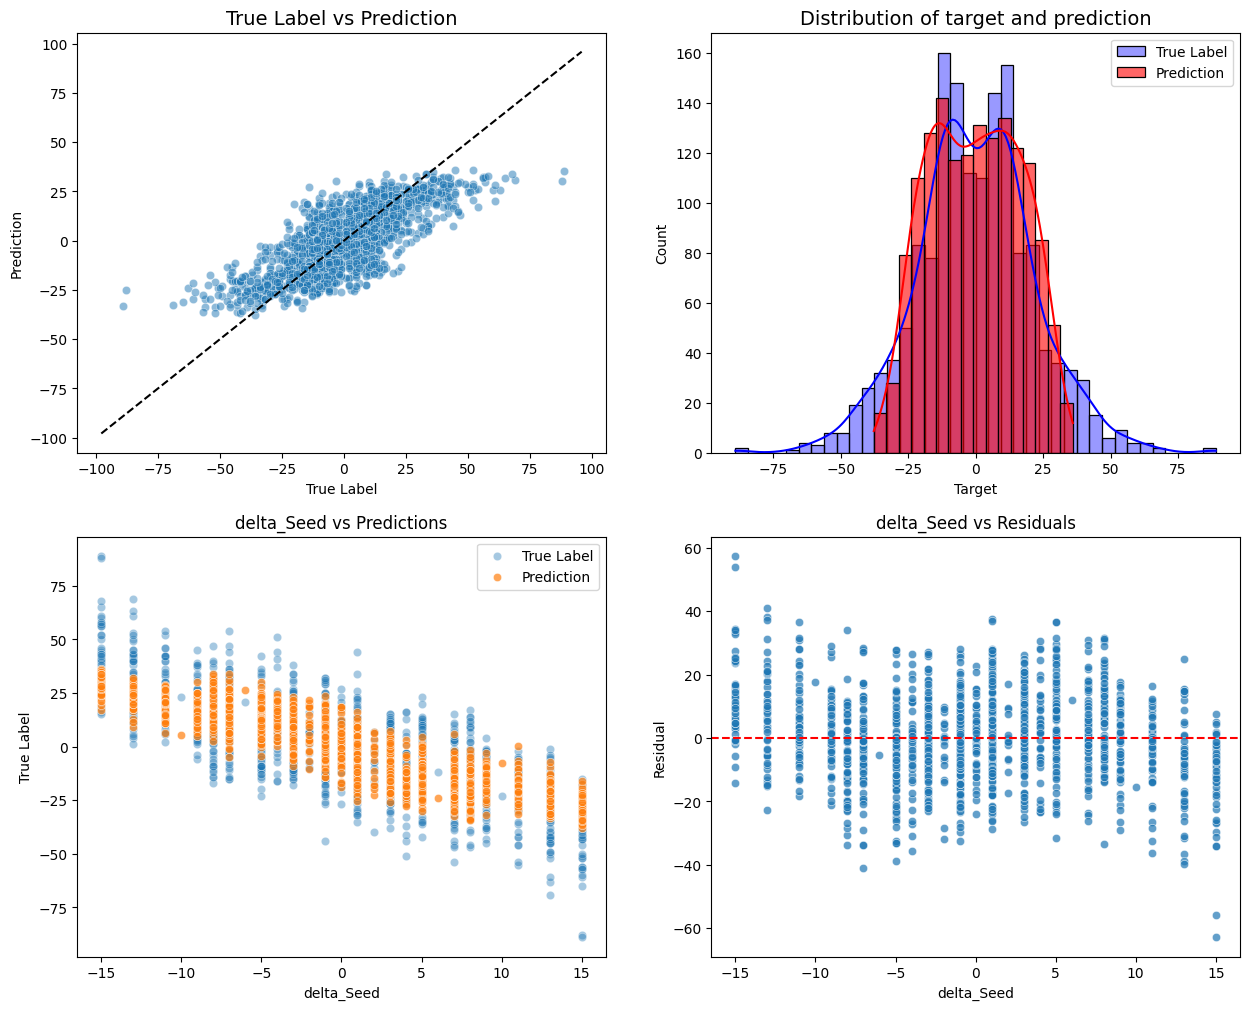

Test score: 13.492222962279934


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


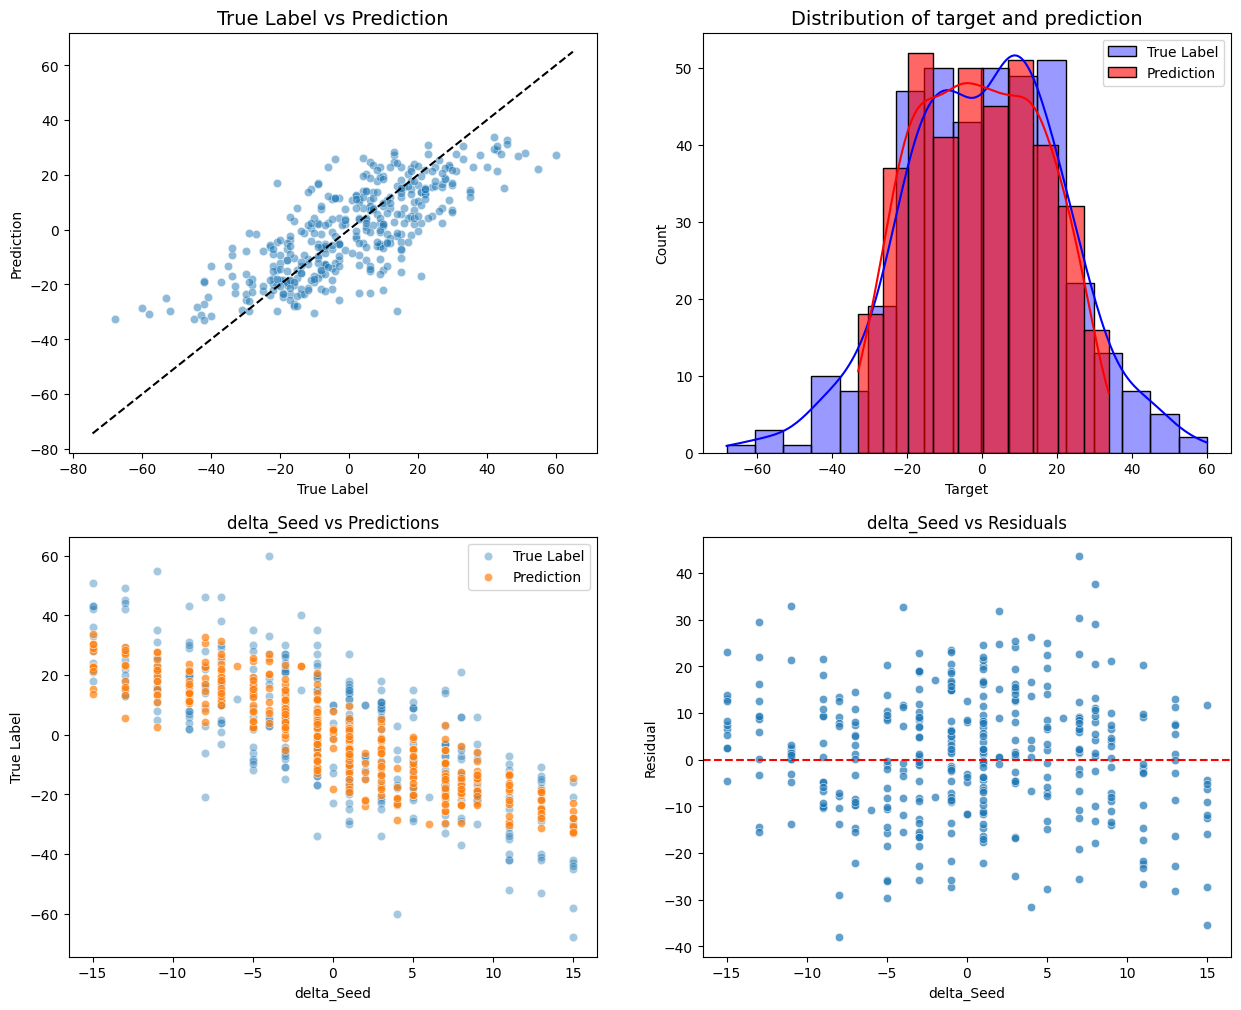

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


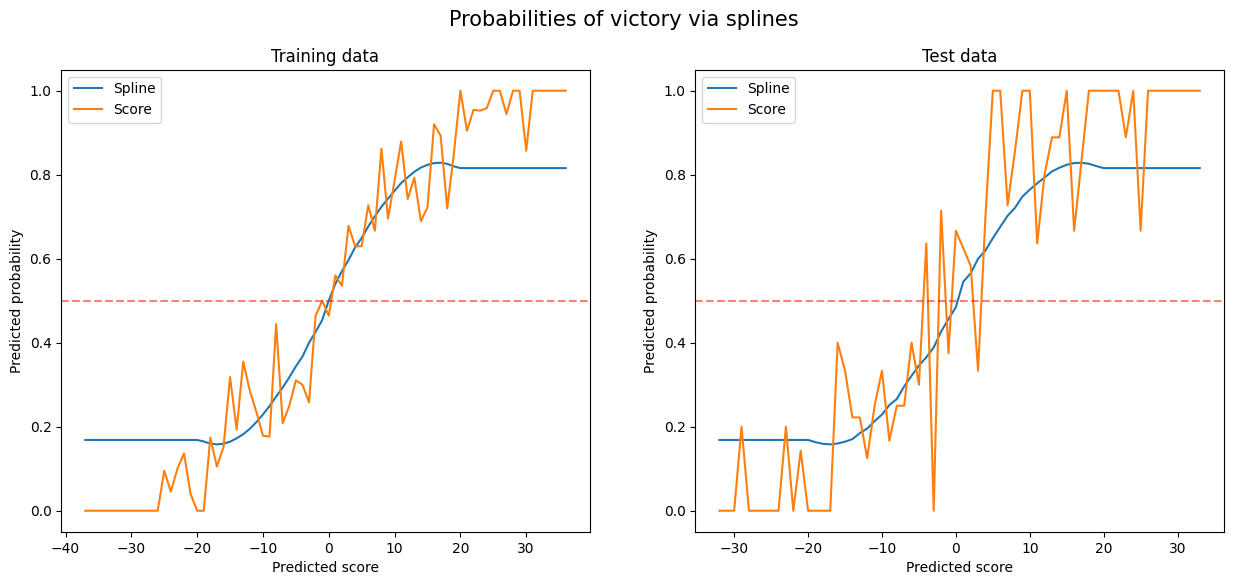

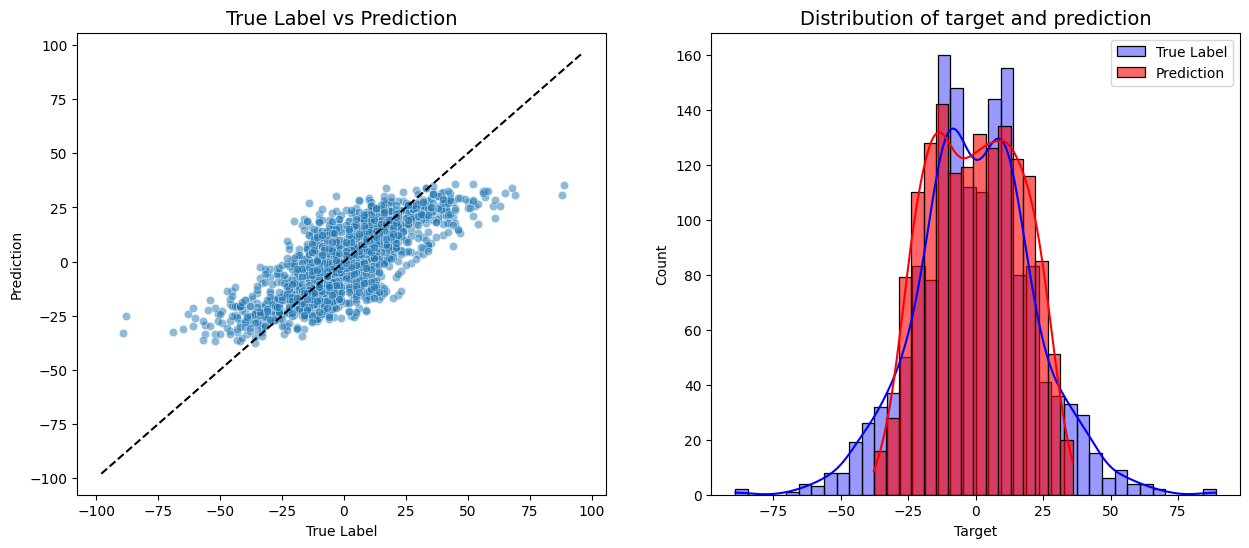

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


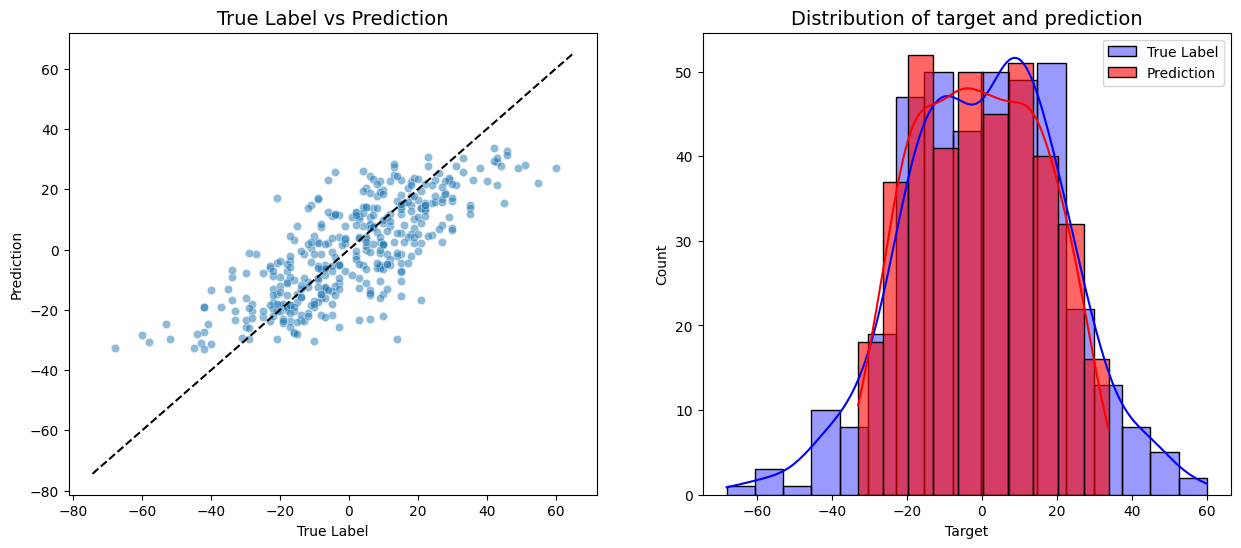

MAE train: 			 10.8443
MAE test: 			 10.7879
RMSE train: 			 13.9653
RMSE test: 			 13.4922
Accuracy train: 		 0.7992
Accuracy test: 			 0.7906
Logloss train: 			 0.4757
Logloss test: 			 0.4657
Brier train: 			 0.1513
Brier test: 			 0.1474
Unsure train: 			 6.89%
Unsure test: 			 6.54%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,10.8443,10.7879,13.9653,13.4922,0.7992,0.7906,0.4757,0.4657,0.1513,0.1474,6.89,6.54


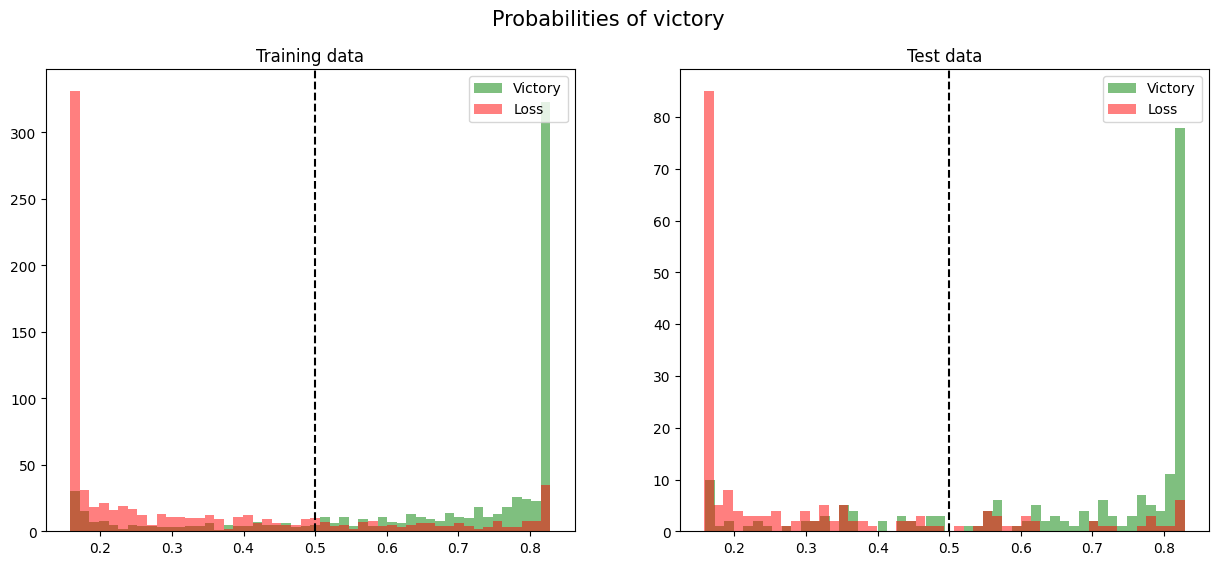

In [20]:
target = df_train["target_points"]

not_imp = [
 'delta_opp_shtg_opportunity',
 'delta_FG3_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_Stl',
 'delta_OR_diff',
 'delta_FGM2_perc',
 'delta_Eff_FG_perc_diff',
 'delta_Opp_True_shooting_perc',
 'delta_possessions',
 'delta_Ast',
 'delta_FG3_ratio',
 'delta_TO',
 'delta_DR_diff',
 'delta_PF',
 'delta_TO_diff',
 'delta_OT_win',
 'delta_FGA3_diff',
 'delta_OR',
 'delta_Opp_eff_shooting_perc'
]

extras = ['T1_Seed',
 'T2_Seed',
 'T1_Blk', 'T2_Blk',
]
FEATURES = [c for c in df_train if "delta" in c and c not in DROP and c not in not_imp ] + extras
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = xgb.XGBRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                         learning_rate=0.01,
                         max_depth=3,
                         reg_lambda=44.06, reg_alpha=11.4,
                         colsample_bytree=0.854,
                          colsample_bylevel=0.597,
                          subsample=0.781,
                         min_child_weight=254.6,
                         early_stopping_rounds=100,
                             eval_metric=mean_squared_error)

pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

    
fit_params = {"verbose": False}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=True, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=20, padd=0.03)

MAE train: 			 10.9907
MAE test: 			 10.8268
RMSE train: 			 14.0094
RMSE test: 			 13.6367
Accuracy train: 		 0.7822
Accuracy test: 			 0.7906
Logloss train: 			 0.4714
Logloss test: 			 0.4619
Brier train: 			 0.1515
Brier test: 			 0.1475
Unsure train: 			 7.35%
Unsure test: 			 8.64%

In [21]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred, clip_val=20, padd=0.03)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [22]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,10.705922,0.170923
True,10.980203,0.131998


In [23]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,10.679766,0.145652
True,11.324455,0.167707


In [24]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,10.902872,0.150040
True,10.442925,0.159797


In [25]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,10.908541,0.149232
True,9.808888,0.184324


In [26]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,10.878487,0.14864
True,9.667642,0.24227


In [27]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,10.876877,0.152131
True,9.039327,0.104203


In [29]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.18599964561130136
1 0.18599829868875395
2 0.18599856871575665
3 0.18600509233502965
4 0.18600668881404084
5 0.18600843047341029
6 0.18601862688811685
7 0.18603727064809805
8 0.18605727021837828
9 0.18607645612706689
10 0.18608862165077458
11 0.1860966324518547
12 0.186106263414951
13 0.18611532683006674
14 0.1861249127886626
15 0.18613374310411732
16 0.18614717272435047
17 0.18616345522634553
18 0.18618277756676915
19 0.18619972942287455
20 0.1862191263625685
21 0.18623994901796234
22 0.18625865580759451
23 0.18627845778779253
24 0.18630114005601936


Round1 + 4%


In [30]:
tmp = df_train.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 4 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 + 4 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 4 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 - 4 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2
tmp["sqr_err_prob"].mean()


0.18599964561130136


0.185925371489329

In [31]:
tmp = df_test.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 4 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 + 4 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 4 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 - 4 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["pred_prob"])**2
tmp["sqr_err_prob"].mean()

0.18070170994569443


0.18108261591113628

In [28]:
df_train.to_csv("data/results/women_train_xgb.csv", index=False)
df_test.to_csv("data/results/women_test_xgb.csv", index=False)